# Part 3: Marginal Interval Analysis

This notebook explains how Machine Gnostics interval analysis compares with a classical 95% confidence interval for the mean.

You will build:
- single-dataset interval examples
- a 2x2 comparison figure across all Anscombe datasets

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from machinegnostics.data import make_anscombe_check_data
from machinegnostics.magcal import IntervalAnalysis

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

plt.style.use("seaborn-v0_8")

## Step 1: Load data and baseline classical RMSE

In [2]:
metrics_all = {}
for ds_id in [1, 2, 3, 4]:
    x, y = make_anscombe_check_data(ds_id)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    cls_model = LinearRegression().fit(x.reshape(-1, 1), y)
    y_pred = cls_model.predict(x.reshape(-1, 1))
    rmse = float(np.sqrt(mean_squared_error(y, y_pred)))

    metrics_all[ds_id] = {
        "x": x,
        "y": y,
        "classical": {
            "mean_y": float(np.mean(y)),
            "rmse": rmse,
        },
    }

print("Loaded all datasets and baseline classical statistics.")

Loaded all datasets and baseline classical statistics.


## Step 2: Run IntervalAnalysis on one dataset
Start small with dataset 1 so the outputs are easy to understand.

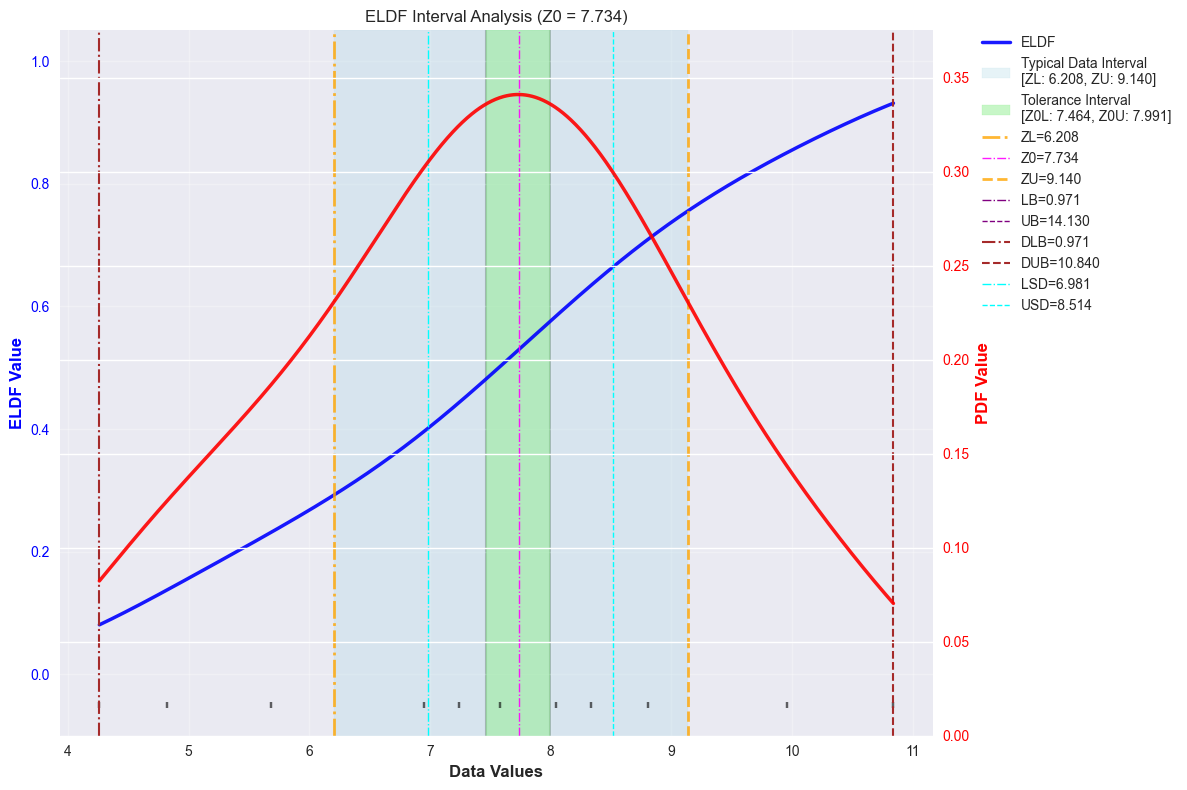

{'LB': 0.9705655112095926,
 'LSB': 4.093196926089609,
 'DLB': 4.26,
 'LCB': 4.26,
 'LSD': 6.980743213404203,
 'ZL': 6.208036678207318,
 'Z0L': 7.463754452214467,
 'Z0': 7.73424,
 'Z0U': 7.991412167832184,
 'ZU': 9.140341765281246,
 'USD': 8.514056786595797,
 'UCB': 10.800519999999999,
 'DUB': 10.84,
 'USB': 11.006803073910396,
 'UB': 14.130361757062035}

In [ ]:
y1 = metrics_all[1]["y"]
ia_y1 = IntervalAnalysis(n_points=100, flush=False, verbose=False)
ia_y1.fit(y1, plot=True)
results_y1 = ia_y1.results()
results_y1

## Step 3: Build the full 2x2 comparison figure
This plot reproduces the interval comparison design used in the reference notebook.

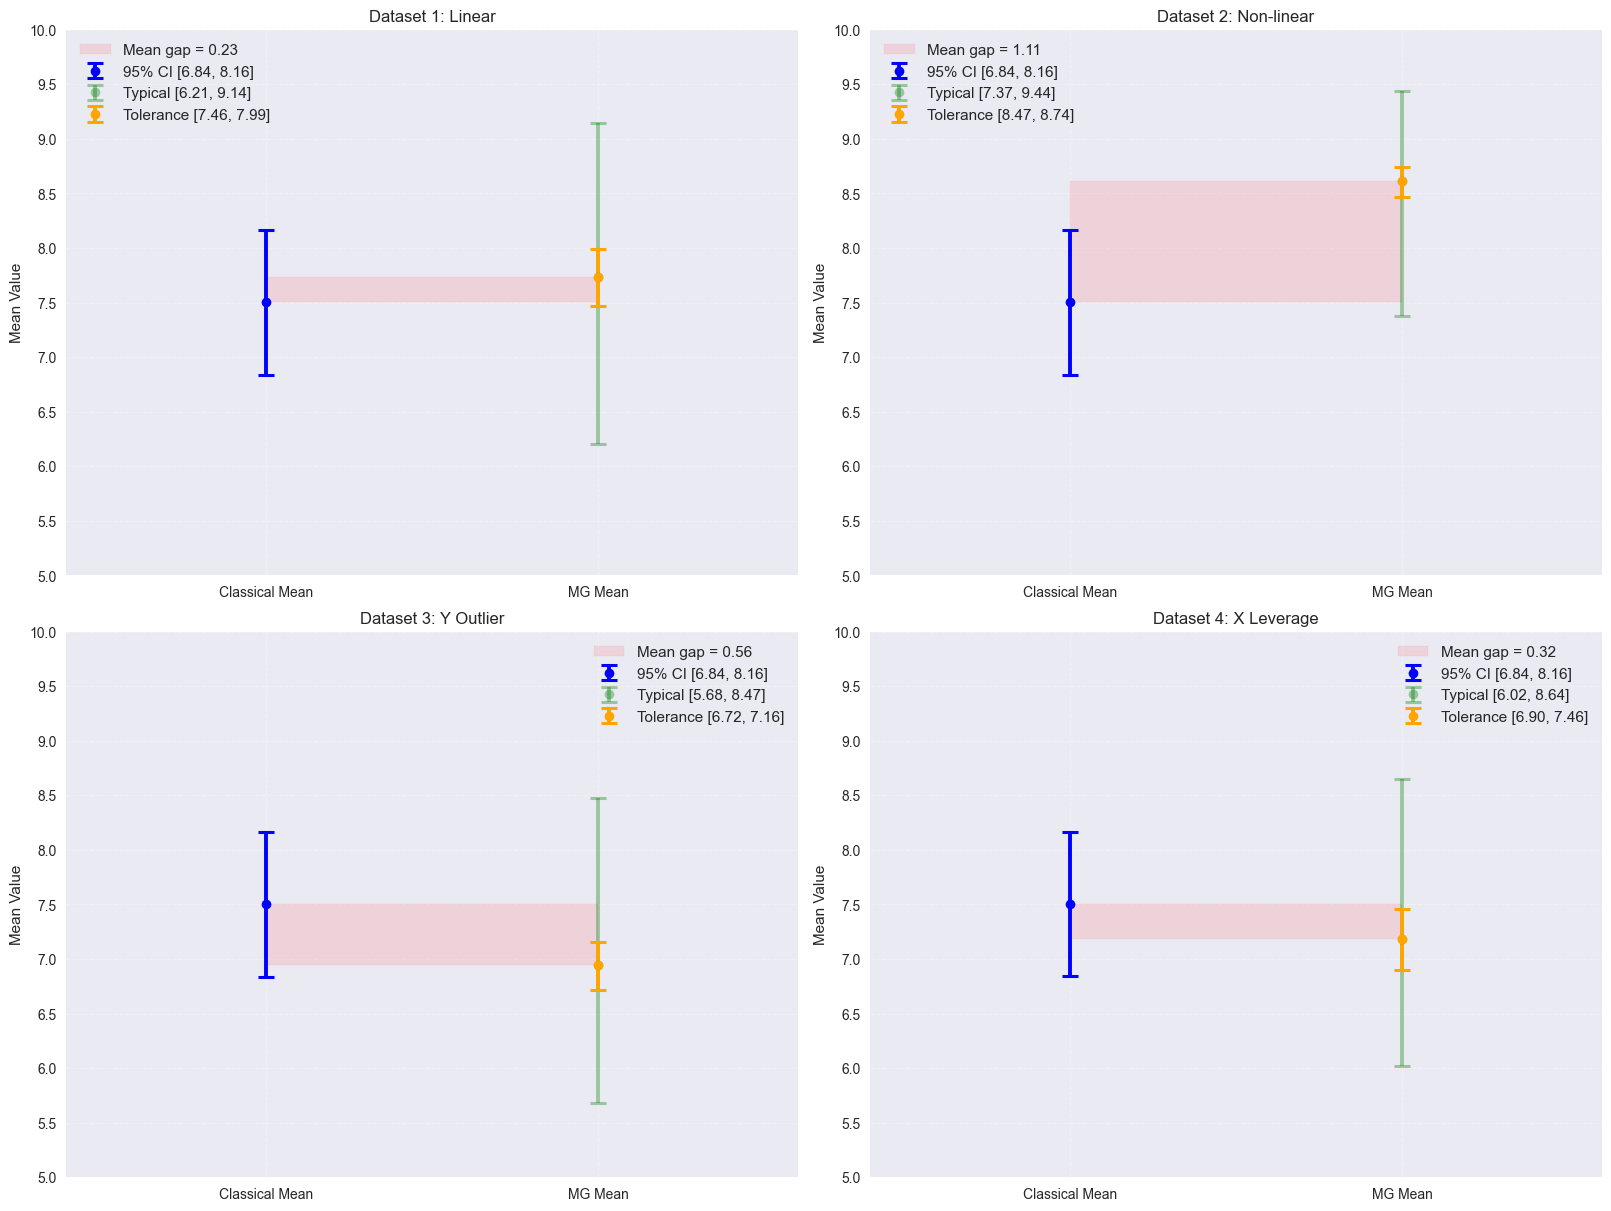

Created 2x2 interval comparison plot.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
axes = axes.ravel()

dataset_names = {
    1: "Linear",
    2: "Non-linear",
    3: "Y Outlier",
    4: "X Leverage",
}

global_y_min = np.inf
global_y_max = -np.inf
summary_rows = []

for i, ds_id in enumerate([1, 2, 3, 4]):
    ax = axes[i]
    y = np.asarray(metrics_all[ds_id]["y"], dtype=float)

    mean_y_stats = float(metrics_all[ds_id]["classical"]["mean_y"])
    rmse_stats = float(metrics_all[ds_id]["classical"]["rmse"])
    margin_95 = 1.96 * (rmse_stats / np.sqrt(len(y)))
    mean_l95 = mean_y_stats - margin_95
    mean_u95 = mean_y_stats + margin_95

    interval_analysis = IntervalAnalysis(flush=False, verbose=False, n_points=100)
    interval_analysis.fit(y)
    results = interval_analysis.results()

    mean_mg = float(results["Z0"])
    typical_interval_lb = float(results["ZL"])
    typical_interval_ub = float(results["ZU"])
    tolerance_interval_lb = float(results["Z0L"])
    tolerance_interval_ub = float(results["Z0U"])

    local_min = min(mean_l95, typical_interval_lb, tolerance_interval_lb, mean_y_stats, mean_mg)
    local_max = max(mean_u95, typical_interval_ub, tolerance_interval_ub, mean_y_stats, mean_mg)
    global_y_min = min(global_y_min, local_min)
    global_y_max = max(global_y_max, local_max)

    gap_low = min(mean_y_stats, mean_mg)
    gap_high = max(mean_y_stats, mean_mg)
    ax.fill_between([0, 1], [gap_low, gap_low], [gap_high, gap_high], color="#ff6b6b", alpha=0.18, label=f"Mean gap = {abs(mean_mg - mean_y_stats):.2f}")

    ax.errorbar(x=0, y=mean_y_stats, yerr=[[mean_y_stats - mean_l95], [mean_u95 - mean_y_stats]], fmt="o", color="blue", label=f"95% CI [{mean_l95:.2f}, {mean_u95:.2f}]", markersize=7, capsize=6, elinewidth=2.8, capthick=2.2)
    ax.errorbar(x=1, y=mean_mg, yerr=[[mean_mg - typical_interval_lb], [typical_interval_ub - mean_mg]], fmt="o", color="green", label=f"Typical [{typical_interval_lb:.2f}, {typical_interval_ub:.2f}]", markersize=7, capsize=6, elinewidth=2.8, capthick=2.2, alpha=0.35)
    ax.errorbar(x=1, y=mean_mg, yerr=[[mean_mg - tolerance_interval_lb], [tolerance_interval_ub - mean_mg]], fmt="o", color="orange", label=f"Tolerance [{tolerance_interval_lb:.2f}, {tolerance_interval_ub:.2f}]", markersize=7, capsize=6, elinewidth=2.8, capthick=2.2)

    ax.set_xlim(-0.6, 1.6)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Classical Mean", "MG Mean"])
    ax.set_ylabel("Mean Value")
    ax.set_title(f"Dataset {ds_id}: {dataset_names[ds_id]}")
    ax.grid(alpha=0.3, linestyle="--", linewidth=0.8)
    ax.legend(fontsize=11, loc="best")

    summary_rows.append({
        "Dataset": ds_id,
        "Classical Mean": mean_y_stats,
        "CI95 Low": mean_l95,
        "CI95 High": mean_u95,
        "MG Mean": mean_mg,
        "Typical Low": typical_interval_lb,
        "Typical High": typical_interval_ub,
        "Tolerance Low": tolerance_interval_lb,
        "Tolerance High": tolerance_interval_ub,
    })

y_min_shared = np.floor((global_y_min - 0.25) * 2) / 2
y_max_shared = np.ceil((global_y_max + 0.25) * 2) / 2
y_ticks = np.arange(y_min_shared, y_max_shared + 0.001, 0.5)

for ax in axes:
    ax.set_ylim(y_min_shared, y_max_shared)
    ax.set_yticks(y_ticks)

plt.show()
print("Created 2x2 interval comparison plot.")

## Step 4: Summary table

In [5]:
interval_summary_df = pd.DataFrame(summary_rows)
interval_summary_df.round(4)

,Dataset,Classical Mean,CI95 Low,CI95 High,MG Mean,Typical Low,Typical High,Tolerance Low,Tolerance High
0,1,7.5009,6.8399,8.1619,7.7342,6.2080,9.1403,7.4638,7.9914
1,2,7.5009,6.8396,8.1623,8.6132,7.3725,9.4403,8.4677,8.7395
2,3,7.5000,6.8391,8.1609,6.9408,5.6827,8.4724,6.7197,7.1587
3,4,7.5009,6.8404,8.1614,7.1858,6.0157,8.6450,6.8951,7.4597
